In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
# διάβασε το αρχείο CSV
df = pd.read_csv("/content/drive/MyDrive/original.csv", sep=",")

# μετατροπή στηλών σε numeric (διορθώνει κόμματα/τελείες)
for col in ["income", "age", "loan"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# έλεγχος missing values
print("Missing values:")
print(df.isnull().sum())

# αντικατάσταση missing με mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# έλεγχος αρνητικών ηλικιών
print("Negative ages:")
print(df[df["age"] < 0])

# διόρθωση αρνητικών ηλικιών με median
median_age = df[df["age"] > 0]["age"].median()
df.loc[df["age"] < 0, "age"] = median_age

# στρογγυλοποίηση σε 2 δεκαδικά ψηφία
df["income"] = df["income"].round(2)
df["age"] = df["age"].round(2)
df["loan"] = df["loan"].round(2)

# εμφάνιση πρώτων γραμμών
print(df.head())

# αποθήκευση καθαρού dataset
df.to_csv("/content/drive/MyDrive/credit_data.csv", index=False, float_format="%.2f")

print("Dataset cleaned ✔️")

Mounted at /content/drive
Missing values:
clientid    0
income      0
age         3
loan        0
default     0
dtype: int64
Negative ages:
    clientid        income        age         loan  default
15        16  50501.726689 -28.218361  3977.287432        0
21        22  32197.620701 -52.423280  4244.057136        0
26        27  63287.038908 -36.496976  9595.286289        0
   clientid    income    age     loan  default
0         1  66155.93  59.02  8106.53        0
1         2  34415.15  48.12  6564.75        0
2         3  57317.17  63.11  8020.95        0
3         4  42709.53  45.75  6103.64        0
4         5  66952.69  18.58  8770.10        1
Dataset cleaned ✔️


In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("original.csv")

# μετατροπή στηλών σε numeric (διορθώνει κόμματα/τελείες)
for col in ["income", "age", "loan"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# έλεγχος missing values
print("Missing values:")
print(df.isnull().sum())

# αντικατάσταση missing με mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# έλεγχος αρνητικών ηλικιών
print("Negative ages:")
print(df[df["age"] < 0])

# διόρθωση αρνητικών ηλικιών με median
median_age = df[df["age"] > 0]["age"].median()
df.loc[df["age"] < 0, "age"] = median_age

# στρογγυλοποίηση σε 2 δεκαδικά ψηφία
df["income"] = df["income"].round(2)
df["age"] = df["age"].round(2)
df["loan"] = df["loan"].round(2)

# εμφάνιση πρώτων γραμμών
print(df.head())

# αποθήκευση καθαρού dataset
df.to_csv("credit_data.csv", index=False, float_format="%.2f")

print("Dataset cleaned ✔️")

Saving original.csv to original (2).csv
Missing values:
clientid    0
income      0
age         3
loan        0
default     0
dtype: int64
Negative ages:
    clientid        income        age         loan  default
15        16  50501.726689 -28.218361  3977.287432        0
21        22  32197.620701 -52.423280  4244.057136        0
26        27  63287.038908 -36.496976  9595.286289        0
   clientid    income    age     loan  default
0         1  66155.93  59.02  8106.53        0
1         2  34415.15  48.12  6564.75        0
2         3  57317.17  63.11  8020.95        0
3         4  42709.53  45.75  6103.64        0
4         5  66952.69  18.58  8770.10        1
Dataset cleaned ✔️


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# =====================================
# LOAD DATASET FROM GOOGLE DRIVE
# =====================================

df = pd.read_csv("/content/drive/MyDrive/credit_data.csv", sep=",")

print("Original dataset shape:", df.shape)

print("\nClass distribution before sampling:")
print(df["default"].value_counts())


# =====================================
# STRATIFIED SAMPLING (300 ROWS)
# =====================================

df_small, _ = train_test_split(
    df,
    train_size=1000,
    stratify=df["default"],
    random_state=42
)

print("\nNew dataset shape:", df_small.shape)

print("\nClass distribution after sampling:")
print(df_small["default"].value_counts())


# =====================================
# SAVE DATASET TO GOOGLE DRIVE
# =====================================

save_path = "/content/drive/MyDrive/new_credit_1000.csv"

df_small.to_csv(save_path, index=False)

print("\nDataset saved successfully to:")
print(save_path)

Original dataset shape: (2000, 5)

Class distribution before sampling:
default
0    1717
1     283
Name: count, dtype: int64

New dataset shape: (1000, 5)

Class distribution after sampling:
default
0    858
1    142
Name: count, dtype: int64

Dataset saved successfully to:
/content/drive/MyDrive/new_credit_1000.csv


In [ ]:
import pandas as pd

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("/content/drive/MyDrive/credit_data.csv")

df = df.drop(columns=["clientid"])
df = df.dropna()

TARGET = "default"

df_new = df.copy()

# =========================
# DISCRETIZATION + BINS
# =========================

df_new["age"], age_bins = pd.qcut(
    df["age"],
    q=3,
    labels=["young","adult","old"],
    retbins=True,
    duplicates="drop"
)

df_new["income"], income_bins = pd.qcut(
    df["income"],
    q=3,
    labels=["low","medium","high"],
    retbins=True,
    duplicates="drop"
)

df_new["loan"], loan_bins = pd.qcut(
    df["loan"],
    q=3,
    labels=["small","medium","large"],
    retbins=True,
    duplicates="drop"
)

# =========================
# PRINT RANGES
# =========================

print("\nAGE ranges:")
print("young :", age_bins[0], "to", age_bins[1])
print("adult :", age_bins[1], "to", age_bins[2])
print("old   :", age_bins[2], "to", age_bins[3])

print("\nINCOME ranges:")
print("low    :", income_bins[0], "to", income_bins[1])
print("medium :", income_bins[1], "to", income_bins[2])
print("high   :", income_bins[2], "to", income_bins[3])

print("\nLOAN ranges:")
print("small  :", loan_bins[0], "to", loan_bins[1])
print("medium :", loan_bins[1], "to", loan_bins[2])
print("large  :", loan_bins[2], "to", loan_bins[3])

# =========================
# TARGET LABELS
# =========================

df_new[TARGET] = df_new[TARGET].replace({
    0: "good",
    1: "bad"
})

# =========================
# SAVE DATASET
# =========================

save_path = "/content/drive/MyDrive/credit_dataset_discretized.csv"

df_new.to_csv(save_path, index=False)

print("\nDataset saved successfully:")
print(save_path)

print("\nPreview:")
print(df_new.head())


AGE ranges:
young : 18.06 to 33.20333333333332
adult : 33.20333333333332 to 48.813333333333325
old   : 48.813333333333325 to 63.97

INCOME ranges:
low    : 20014.49 to 36971.27
medium : 36971.27 to 53648.93666666666
high   : 53648.93666666666 to 69995.69

LOAN ranges:
small  : 1.38 to 2574.2966666666666
medium : 2574.2966666666666 to 5599.5499999999965
large  : 5599.5499999999965 to 13766.05

Dataset saved successfully:
/content/drive/MyDrive/credit_dataset_discretized.csv

Preview:
   income    age   loan default
0    high    old  large    good
1     low  adult  large    good
2    high    old  large    good
3  medium  adult  large    good
4    high  young  large     bad


In [ ]:
import pandas as pd

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("/content/drive/MyDrive/credit_dataset_discretized.csv")

TARGET = "default"

features = ["age", "income", "loan"]

# =========================
# COUNT EACH COMBINATION
# =========================

counts = df.groupby(features + [TARGET]).size().reset_index(name="count")

print("\nOriginal combinations:\n")
print(counts)

# =========================
# FIND MAJORITY CLASS
# =========================

majority = (
    counts.sort_values("count", ascending=False)
    .drop_duplicates(subset=features)
)

print("\nMajority class per combination:\n")
print(majority)

# =========================
# MERGE BACK TO DATASET
# =========================

clean_df = pd.merge(
    df,
    majority[features + [TARGET]],
    on=features,
    suffixes=("", "_majority")
)

# =========================
# KEEP ONLY MAJORITY
# =========================

clean_df = clean_df[clean_df[TARGET] == clean_df[TARGET + "_majority"]]

clean_df = clean_df.drop(columns=[TARGET + "_majority"])

print("\nClean dataset size:", len(clean_df))

# =========================
# SAVE CLEAN DATASET
# =========================

clean_df.to_csv(
    "/content/drive/MyDrive/credit_dataset_clean.csv",
    index=False
)

print("\nClean dataset saved successfully.")


Original combinations:

      age  income    loan default  count
0   adult    high   large     bad      9
1   adult    high   large    good    105
2   adult    high  medium    good     54
3   adult    high   small    good     46
4   adult     low   large     bad      2
5   adult     low   large    good     21
6   adult     low  medium     bad      9
7   adult     low  medium    good     95
8   adult     low   small    good    117
9   adult  medium   large     bad      8
10  adult  medium   large    good     71
11  adult  medium  medium    good     76
12  adult  medium   small    good     53
13    old    high   large    good    121
14    old    high  medium    good     54
15    old    high   small    good     38
16    old     low   large    good     14
17    old     low  medium    good    107
18    old     low   small    good    104
19    old  medium   large    good     88
20    old  medium  medium    good     64
21    old  medium   small    good     77
22  young    high   large     ba

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
from xml.dom import minidom
import uuid

# ============================================================
# 1. LOAD SYMBOLIC DATASET
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/credit_dataset_clean.csv")

df.columns = df.columns.str.strip()

# αν υπάρχει id το αφαιρούμε
if "clientid" in df.columns:
    df = df.drop(columns=["clientid"])

TARGET = "default"

print(df.head())
print(df.columns)

# ============================================================
# 2. ENSURE SYMBOLIC DATA (PRISM REQUIREMENT)
# ============================================================

df = df.astype(str)

# ============================================================
# 3. CANONICAL PRISM
# ============================================================

class CanonicalPrism:

    def __init__(self):
        self.rules = {}
        self.target_col = None
        self.default_target = None


    def _best_term(self, df, target, cls, used):

        best = None
        best_prob = -1

        for col in df.columns:

            if col == target or col in used:
                continue

            for val in df[col].unique():

                sub = df[df[col] == val]

                if sub.empty:
                    continue

                prob = (sub[target] == cls).mean()

                if prob > best_prob:

                    best_prob = prob
                    best = (col, val)

        return best


    def _learn_class(self, df, target, cls):

        remaining = df.copy()
        rules = []

        while (remaining[target] == cls).any():

            rule = []
            used = []
            work = remaining.copy()

            while True:

                term = self._best_term(work, target, cls, used)

                if term is None:
                    break

                col, val = term

                rule.append((col, val))
                used.append(col)

                work = work[work[col] == val]

                if (work[target] == cls).all():
                    break

            rules.append(rule)

            remaining = remaining.drop(work.index)

        return rules


    def fit(self, df, target):

        self.target_col = target

        for cls in df[target].unique():

            self.rules[cls] = self._learn_class(df, target, cls)

        self.default_target = df[target].mode()[0]

        return self.rules


# ============================================================
# 4. TRAIN PRISM
# ============================================================

prism = CanonicalPrism()

prism.fit(df, TARGET)

# ============================================================
# 5. PRINT RULES
# ============================================================

print("\n📌 FINAL PRISM RULES:\n")

for cls, rules in prism.rules.items():

    print(f"=== CLASS {cls} ===")

    for i, rule in enumerate(rules, 1):

        conditions = [f"{a} = {v}" for a, v in rule]

        print(f"Rule {i}: IF {' AND '.join(conditions)} THEN {cls}")

    print()

# ============================================================
# 6. EXPORT PRISM → DMN
# ============================================================

def export_prism_to_dmn(prism, decision_name, filename, feature_columns):

    inputs = [c for c in feature_columns if c != prism.target_col]

    definitions = ET.Element(
        "definitions",
        {
            "xmlns": "https://www.omg.org/spec/DMN/20191111/MODEL/",
            "xmlns:camunda": "http://camunda.org/schema/1.0/dmn",
            "id": f"def_{uuid.uuid4()}",
            "name": decision_name,
            "namespace": "http://camunda.org/schema/1.0/dmn"
        }
    )

    decision = ET.SubElement(
        definitions,
        "decision",
        {"id": f"dec_{uuid.uuid4()}", "name": decision_name}
    )

    table = ET.SubElement(
        decision,
        "decisionTable",
        {"id": f"dt_{uuid.uuid4()}", "hitPolicy": "FIRST"}
    )

    # Inputs
    for inp in inputs:

        i = ET.SubElement(table, "input")

        expr = ET.SubElement(i, "inputExpression", {"typeRef": "string"})

        ET.SubElement(expr, "text").text = inp

    # Output
    ET.SubElement(
        table,
        "output",
        {"name": prism.target_col, "typeRef": "string"}
    )

    # Rules
    for cls, rules in prism.rules.items():

        for rule in rules:

            r = ET.SubElement(table, "rule")

            rule_map = dict(rule)

            for inp in inputs:

                e = ET.SubElement(r, "inputEntry")

                ET.SubElement(e, "text").text = (
                    f'"{rule_map[inp]}"' if inp in rule_map else "-"
                )

            out = ET.SubElement(r, "outputEntry")

            ET.SubElement(out, "text").text = cls

    # Default rule
    default_rule = ET.SubElement(table, "rule")

    for _ in inputs:

        e = ET.SubElement(default_rule, "inputEntry")

        ET.SubElement(e, "text").text = "-"

    out = ET.SubElement(default_rule, "outputEntry")

    ET.SubElement(out, "text").text = prism.default_target


    xml = minidom.parseString(
        ET.tostring(definitions, encoding="utf-8")
    ).toprettyxml(indent="  ")

    with open("credit_prism_rules.dmn", "w", encoding="utf-8") as f:

        f.write(xml)

    print("\n✅ DMN file created: credit_prism_rules.dmn")


# ============================================================
# 7. CREATE DMN
# ============================================================

export_prism_to_dmn(
    prism,
    decision_name="PRISM Credit Default",
    filename="credit_prism_rules.dmn",
    feature_columns=df.columns.tolist()
)

   income    age   loan default
0    high    old  large    good
1     low  adult  large    good
2    high    old  large    good
3  medium  adult  large    good
4    high  young  large     bad
Index(['income', 'age', 'loan', 'default'], dtype='object')

📌 FINAL PRISM RULES:

=== CLASS good ===
Rule 1: IF age = old THEN good
Rule 2: IF age = adult THEN good
Rule 3: IF loan = small THEN good
Rule 4: IF loan = medium AND income = high THEN good
Rule 5: IF loan = medium AND income = medium THEN good

=== CLASS bad ===
Rule 1: IF age = young AND loan = large THEN bad
Rule 2: IF age = young AND income = low AND loan = medium THEN bad


✅ DMN file created: credit_prism_rules.dmn


✅ DMN generated: credit_cart_rules.dmn


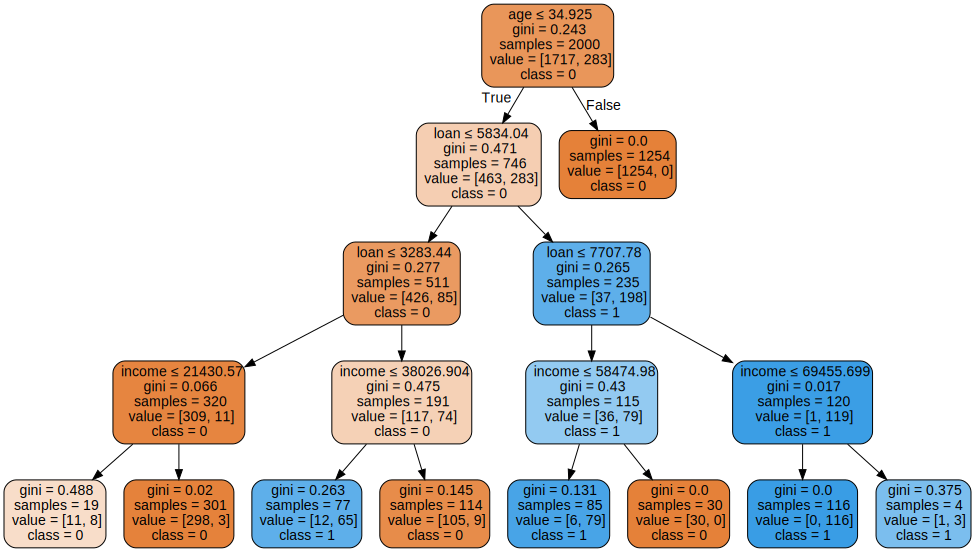

In [ ]:
import numpy as np
import pandas as pd
import xml.etree.ElementTree as et
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz

# ============================================================
# DATASET (FROM GOOGLE DRIVE)
# ============================================================

# ============================================================
# DATASET (FROM GOOGLE DRIVE)
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/credit_data.csv")

# convert target
df["loan_status"] = df["default"].replace({
    0: "good",
    1: "bad"
})
# ============================================================
# DATASET (FROM GOOGLE DRIVE)
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/credit_data.csv")

# αφαιρούμε το ID
df = df.drop(columns=["clientid"])

# convert target
df["loan_status"] = df["default"].replace({
    0: "good",
    1: "bad"
})

TARGET = "default"

y = df[TARGET]

X = df.drop(columns=[TARGET, "default", "loan_status"])
# ============================================================
# TRAIN DECISION TREE
# ============================================================

clf = DecisionTreeClassifier(max_depth=4, random_state=0)

clf.fit(X.values, y.values)

# ============================================================
# xmlDmn CLASS
# ============================================================

class xmlDmn:

    def __init__(self):
        self._id = 0

        self.root = et.Element(
            "definitions",
            {
                "xmlns": "http://www.omg.org/spec/DMN/20151101/dmn.xsd",
                "id": "definitions_1",
                "name": "Loan Decision Model",
                "namespace": "http://example.org/dmn",
            },
        )

        self.decision = et.SubElement(
            self.root, "decision", {"id": "decision_1", "name": "Cart Credit"}
        )

        self.table = et.SubElement(
            self.decision,
            "decisionTable",
            {"id": "decisionTable_1", "hitPolicy": "UNIQUE"},
        )

    def _gen(self, prefix):
        self._id += 1
        return f"{prefix}{self._id}"

    def create_columns(self, features, target):
        for f in features:
            inp = et.SubElement(self.table, "input", {"id": self._gen("in_")})
            expr = et.SubElement(
                inp,
                "inputExpression",
                {"id": self._gen("expr_"), "typeRef": "double"},
            )
            et.SubElement(expr, "text").text = f

        et.SubElement(
            self.table,
            "output",
            {"id": self._gen("out_"), "name": target, "typeRef": "string"},
        )

    def add_rule(self, conditions, output):
        r = et.SubElement(self.table, "rule", {"id": self._gen("rule_")})

        for c in conditions:
            cell = et.SubElement(r, "inputEntry", {"id": self._gen("cell_")})
            et.SubElement(cell, "text").text = c

        out = et.SubElement(r, "outputEntry", {"id": self._gen("outc_")})
        et.SubElement(out, "text").text = str(output)

    def save(self, filename):
        et.ElementTree(self.root).write(
            filename, encoding="utf-8", xml_declaration=True
        )
        return filename

# ============================================================
# DECISION TREE → DMN CONVERTER
# ============================================================

class clfDmn:

    def __init__(self, clf, X, y, target):
        self.clf = clf
        self.X = X
        self.y = y
        self.features = X.columns.tolist()
        self.target = target
        self.xml = xmlDmn()

    def generate(self):
        tree_ = self.clf.tree_
        left = tree_.children_left
        right = tree_.children_right
        threshold = tree_.threshold

        self.xml.create_columns(self.features, self.target)

        paths = self.clf.decision_path(self.X.values)
        leaves = np.where((left == -1) & (right == -1))[0]

        for leaf in leaves:
            rows = paths.getcol(leaf).nonzero()[0]
            if len(rows) == 0:
                continue

            sample = rows[0]
            nodes = paths.indices[
                paths.indptr[sample] : paths.indptr[sample + 1]
            ]

            rule = ["-" for _ in self.features]

            for i in range(len(nodes) - 1):
                n = nodes[i]
                f_id = tree_.feature[n]
                if f_id < 0:
                    continue

                thr = threshold[n]
                if nodes[i + 1] == left[n]:
                    rule[f_id] = f"<= {thr:.2f}"
                else:
                    rule[f_id] = f"> {thr:.2f}"

            cls_label = self.clf.classes_[np.argmax(tree_.value[leaf])]

            # convert 0/1 → good/bad
            if cls_label == 0:
                cls_label = "good"
            else:
                cls_label = "bad"
            self.xml.add_rule(rule, cls_label)

        return self.xml.save("credit_cart_rules.dmn")

# ============================================================
# RUN DMN GENERATION
# ============================================================

converter = clfDmn(clf, X, y, TARGET)
print("✅ DMN generated:", converter.generate())

# ============================================================
# VISUALIZE TREE
# ============================================================

dot = tree.export_graphviz(
    clf,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_], # Convert class_names to strings
    filled=True,
    rounded=True,
    label="all",
    special_characters=True
)

# ============================================================
# SAVE TREE AS IMAGE
# ============================================================

graph = graphviz.Source(dot)

graph.format = "png"
graph.render("loan_decision_tree", view=False)

graphviz.Source(dot)